# Análisis de perfil y desempeño 01/06/2026

# Librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
from datetime import date
import scipy.stats as stats
import numpy as np
import plotly.graph_objs as go

# Documento

In [2]:
df_RRHH = pd.read_csv('../../Data/clean/clean_data_01062026.csv')
df_RRHH

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
0,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-05-25
1,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-05-25
2,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-05-25
3,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-05-25
4,9,12.0,Piel y tejido subcutáneo,9.0,Septiembre,3,Martes,3,Verano,228,...,2,0,0,1,65,172,22,22.0,112,2026-05-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,14,11.0,Sistema digestivo,5.0,Mayo,2,Lunes,2,Primavera,155,...,2,1,0,0,95,196,25,24.7,120,2026-06-01
840,36,13.0,Sistema musculoesquelético,10.0,Octubre,4,Miércoles,4,Otoño,118,...,1,1,0,0,98,178,31,30.9,120,2026-06-01
841,9,6.0,Sistema nervioso,1.0,Enero,3,Martes,1,Invierno,228,...,2,0,0,1,65,172,22,22.0,120,2026-06-01
842,28,9.0,Sistema circulatorio,1.0,Enero,3,Martes,1,Invierno,225,...,1,0,0,2,69,169,24,24.2,112,2026-06-01


In [3]:
df_RRHH.info()

<class 'pandas.DataFrame'>
RangeIndex: 844 entries, 0 to 843
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       844 non-null    int64  
 1   Reason_absence           802 non-null    float64
 2   Reason_absence_name      802 non-null    str    
 3   Month_absence            841 non-null    float64
 4   Month_absence_name       841 non-null    str    
 5   Day_week                 844 non-null    int64  
 6   Day_week_name            844 non-null    str    
 7   Seasons                  844 non-null    int64  
 8   Seasons_name             844 non-null    str    
 9   Transportation_expense   844 non-null    int64  
 10  Distance_Residence_Work  844 non-null    int64  
 11  Service_time             844 non-null    int64  
 12  Age                      844 non-null    int64  
 13  Work_load_Average_day    844 non-null    float64
 14  Hit_target               844 non-null

In [4]:
df_RRHH.shape

(844, 28)

In [5]:
df_RRHH.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,844.0,26.125592,26.389515,1.000,10.000,20.000,33.000,136.000
Reason_absence,802.0,20.314214,7.176987,1.000,13.000,23.000,27.000,28.000
Month_absence,841.0,6.527943,3.400209,1.000,4.000,7.000,9.000,12.000
Day_week,844.0,3.928910,1.416617,2.000,3.000,4.000,5.000,6.000
Seasons,844.0,2.523697,1.095946,1.000,2.000,3.000,3.000,4.000
Transportation_expense,844.0,220.477488,67.456296,118.000,179.000,225.000,260.000,388.000
Distance_Residence_Work,844.0,29.422986,14.748504,5.000,16.000,26.000,49.000,52.000
Service_time,844.0,12.582938,4.425366,1.000,9.000,12.500,16.000,29.000
Age,844.0,36.453791,6.552751,27.000,31.000,37.000,40.000,58.000
Work_load_Average_day,844.0,271.957630,39.054208,205.917,244.387,264.604,294.217,378.884


In [6]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

Listas de columnas numéricas y categóricas separadas de todo el dataset (con 'ID')

In [7]:
num = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Work_load_Average_day', 'Hit_target','Pet', 'Son',
       'Weight', 'Height', 'Absenteeism_hours', 'BMI_calculated']

cat = ['ID','Reason_absence', 'Month_absence', 'Day_week',
       'Seasons', 'Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

Listas de columnas numéricas y categóricas separadas para el estudio de individuo (_ID) y las que hay más de una por individuo (_all) (con 'ID)

In [8]:
variables_ind = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Pet', 'Son', 'Weight', 'Height', 'BMI_calculated', 'Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

num_ID = ['ID','Transportation_expense', 'Distance_Residence_Work', 'Service_time',
       'Age', 'Pet', 'Son', 'Weight', 'Height', 'BMI_calculated']
cat_ID = ['ID','Disciplinary_failure', 'Education',
       'Social_drinker', 'Social_smoker']

num_all = ['ID','Work_load_Average_day', 'Hit_target','Absenteeism_hours']

cat_all = ['ID','Reason_absence', 'Month_absence', 'Day_week',
       'Seasons']

# Pregunta de negocio

**Analista de Perfil i Desempeño Professional:**  
- Quines característiques dels empleats estan associades amb un millor acompliment laboral
- com podem utilitzar aquesta informació per dissenyar estratègies de selecció, capacitació i retenció més efectives?

## Análisis descriptivo

### Distribución variable hit target (histograma y boxplot [outliers])

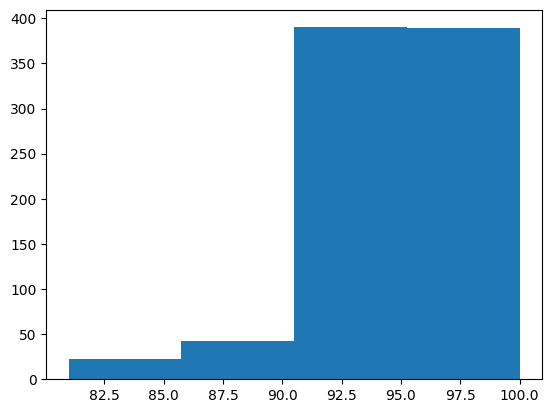

In [9]:
plt.hist(df_RRHH['Hit_target'], bins=4)
plt.show()

In [10]:
df_RRHH['Hit_target'].value_counts(normalize=True)*100

Hit_target
93     14.691943
99     14.099526
97     11.848341
92     10.426540
96      9.952607
95      9.952607
98      8.767773
91      6.516588
94      4.620853
88      3.436019
81      2.725118
87      1.540284
100     1.421801
Name: proportion, dtype: float64

In [11]:
df_RRHH['Hit_target'].unique()

array([ 97,  98,  93,  92,  99,  94,  88,  96,  95,  81, 100,  91,  87])

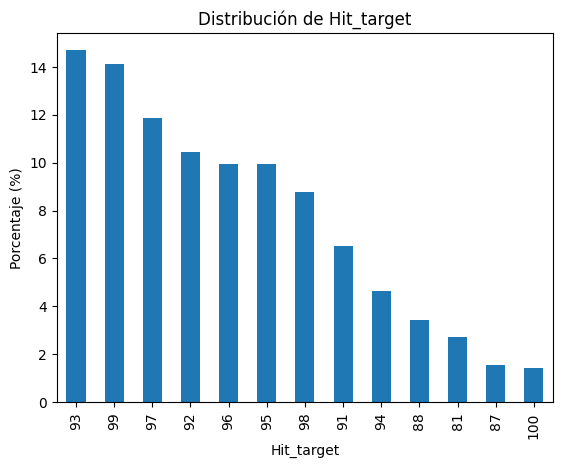

In [12]:
(df_RRHH['Hit_target']
 .value_counts(normalize=True)
 .mul(100)
 .plot(kind='bar'))

plt.ylabel('Porcentaje (%)')
plt.xlabel('Hit_target')
plt.title('Distribución de Hit_target')
plt.show()

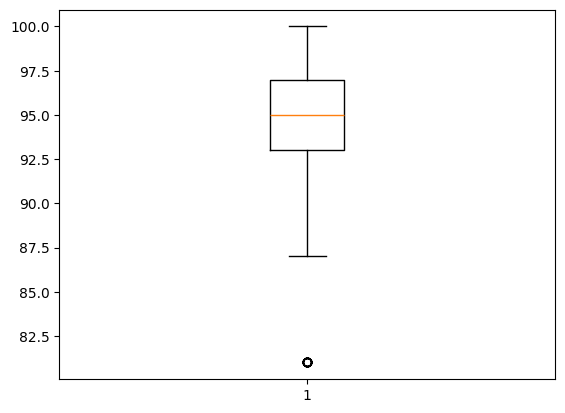

In [13]:
plt.boxplot(df_RRHH['Hit_target'])
plt.show()

Para saber el valor del outlier he mirado qué valores quedan fuera del cuartil Q1 y Q3.  
El valor **outlier es 81** (hay 23 registros), que es el mínimo, el siguiente valor es 88.

In [14]:
col = df_RRHH['Hit_target']

Q1 = col.quantile(0.25)
Q3 = col.quantile(0.75)
IQR = Q3 - Q1

limit_inferior = Q1 - 1.5 * IQR
limit_superior = Q3 + 1.5 * IQR

outliers = df_RRHH[(col < limit_inferior) | (col > limit_superior)]

In [15]:
outliers

,ID,Reason_absence,Reason_absence_name,Month_absence,Month_absence_name,Day_week,Day_week_name,Seasons,Seasons_name,Transportation_expense,...,Son,Social_drinker,Social_smoker,Pet,Weight,Height,Body_mass_index,BMI_calculated,Absenteeism_hours,importacion
20,15,7.0,Ojo y anexos,3.0,Marzo,2,Lunes,2,Primavera,291,...,1,1,0,1,73,171,25,25.0,40,2026-05-25
25,24,9.0,Sistema circulatorio,3.0,Marzo,4,Miércoles,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,32,2026-05-25
36,11,19.0,"Lesiones, intoxicaciones y consecuencias externas",3.0,Marzo,4,Miércoles,1,Invierno,289,...,2,1,0,1,90,172,30,30.4,24,2026-05-25
52,24,9.0,Sistema circulatorio,3.0,Marzo,2,Lunes,1,Invierno,246,...,0,1,0,0,67,170,23,23.2,16,2026-05-25
148,3,11.0,Sistema digestivo,3.0,Marzo,2,Lunes,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
149,3,13.0,Sistema musculoesquelético,3.0,Marzo,4,Miércoles,1,Invierno,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
150,5,26.0,Ausencia injustificada,3.0,Marzo,4,Miércoles,2,Primavera,235,...,1,1,0,0,106,167,38,38.0,8,2026-05-25
151,3,13.0,Sistema musculoesquelético,3.0,Marzo,2,Lunes,2,Primavera,179,...,0,1,0,0,89,170,31,30.8,8,2026-05-25
301,15,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,291,...,1,1,0,1,73,171,25,25.0,4,2026-05-25
302,20,28.0,Consulta dental,3.0,Marzo,6,Viernes,1,Invierno,260,...,4,1,0,0,65,168,23,23.0,4,2026-05-25


### Para cada uno de los grupos de las otras variables

In [16]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

#### Individuo

In [17]:
df_RRHH.columns

Index(['ID', 'Reason_absence', 'Reason_absence_name', 'Month_absence',
       'Month_absence_name', 'Day_week', 'Day_week_name', 'Seasons',
       'Seasons_name', 'Transportation_expense', 'Distance_Residence_Work',
       'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
       'Disciplinary_failure', 'Education', 'Education_name', 'Son',
       'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
       'Body_mass_index', 'BMI_calculated', 'Absenteeism_hours',
       'importacion'],
      dtype='str')

In [18]:
df_RRHH_ind = df_RRHH[[
        'ID', 'Transportation_expense', 'Distance_Residence_Work',
        'Service_time', 'Age', 'Work_load_Average_day', 'Hit_target',
        'Disciplinary_failure', 'Education', 'Education_name', 'Son',
        'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
        'BMI_calculated', 'Absenteeism_hours',
        ]].copy()

In [19]:
df_RRHH_ind.shape

(844, 18)

In [20]:
df_RRHH_ind.sample(5)

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,Hit_target,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Absenteeism_hours
696,36,118,13,18,50,239.554,97,1,1,Secundaria,1,1,0,0,98,178,30.9,0
530,15,291,31,12,40,249.797,93,0,1,Secundaria,1,1,0,1,73,171,25.0,2
208,17,179,22,17,40,249.797,93,0,2,Grado,2,0,1,0,63,170,21.8,8
800,98,225,26,9,28,268.519,93,0,1,Secundaria,1,0,0,2,69,169,24.2,4
10,22,179,26,9,30,265.017,88,0,3,Posgrado,0,0,0,0,56,171,19.2,64


In [21]:
cols_first = [
    'Transportation_expense', 'Distance_Residence_Work',
    'Service_time', 'Age',
    'Disciplinary_failure', 'Education', 'Education_name', 'Son',
    'Social_drinker', 'Social_smoker', 'Pet', 'Weight', 'Height',
    'BMI_calculated'
]

df_RRHH_ind_grouped = (
    df_RRHH_ind
    .groupby('ID')
    .agg({
        **{col: 'first' for col in cols_first},
        'Work_load_Average_day': 'median',
        'Hit_target': 'median',
        'Absenteeism_hours': 'sum'
    })
    .reset_index()
)

df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']] = (
    df_RRHH_ind_grouped[['Work_load_Average_day', 'Hit_target']]
    .round(3)
)

In [22]:
df_RRHH_ind_grouped

,ID,Transportation_expense,Distance_Residence_Work,Service_time,Age,Disciplinary_failure,Education,Education_name,Son,Social_drinker,Social_smoker,Pet,Weight,Height,BMI_calculated,Work_load_Average_day,Hit_target,Absenteeism_hours
0,1,235,11,14,37,0,3,Posgrado,1,0,0,1,88,172,29.7,249.797,95.0,121
1,2,235,29,12,48,0,1,Secundaria,1,0,1,5,88,163,33.1,218.104,92.0,25
2,3,179,51,18,38,0,1,Secundaria,0,1,0,0,89,170,30.8,253.465,96.0,482
3,4,118,14,13,40,0,1,Secundaria,1,1,0,8,98,170,33.9,271.219,95.0,0
4,5,235,20,13,43,0,1,Secundaria,1,1,0,0,106,167,38.0,265.017,93.0,104
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,132,118,13,18,50,0,1,Secundaria,1,1,0,0,98,178,30.9,244.387,98.0,3
132,133,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,241.476,92.0,3
133,134,118,10,10,37,0,1,Secundaria,0,0,0,0,83,172,28.1,268.519,93.0,8
134,135,225,26,9,28,0,1,Secundaria,1,0,0,2,69,169,24.2,378.884,92.0,8


In [ ]:
for col in num:
    print(col)
    plt.hist(df_RRHH[col])
    plt.show()
    print(df_RRHH[col].nunique())
    print(df_RRHH[col].unique())
    print('----')

## Tamaño de muestra

In [ ]:
df_RRHH.info()

In [ ]:
# Función para calcular la moda de variables categóricas/temporales
def moda(x):
    m = x.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

df_emp = df_RRHH.groupby('ID').agg(
    # Variable dependiente agregada a nivel empleado
    Hit_target_median=('Hit_target', 'median'),
    Hit_target_mean=('Hit_target', 'mean'),

    # Número de solicitudes / registros de ausencia por empleado
    num_absences=('ID', 'size'),

    # Variables numéricas del empleado
    Age=('Age', 'first'),
    Service_time=('Service_time', 'first'),
    Distance_Residence_Work=('Distance_Residence_Work', 'first'),
    Transportation_expense=('Transportation_expense', 'first'),

    # Variables que pueden variar por registro
    Absenteeism_hours_total=('Absenteeism_hours', 'sum'),
    Absenteeism_hours_median=('Absenteeism_hours', 'median'),
    # Work_load_Average_day_median=('Work_load_Average_day', 'median'),

    # Variables categóricas/dummy del empleado
    Disciplinary_failure=('Disciplinary_failure', 'first'),
    Education=('Education', 'first'),
    Son=('Son', 'first'),
    Social_drinker=('Social_drinker', 'first'),
    Social_smoker=('Social_smoker', 'first'),
    Pet=('Pet', 'first'),

    # Variables temporales: valor más frecuente por empleado
    Month_absence_mode=('Month_absence', moda),
    Seasons_mode=('Seasons', moda)
).reset_index()

In [ ]:
variables_grupo = [
    'Disciplinary_failure',
    'Education',
    'Son',
    'Social_drinker',
    'Social_smoker',
    'Pet'
]

for var in variables_grupo:
    #print(f"\n{var}")
    print(df_emp[var].value_counts(dropna=False))
    print(df_emp[var].value_counts(normalize=True, dropna=False) * 100)

Cleaning

In [ ]:
df_RRHH[df_RRHH['ID'] == 28][
    df_RRHH[df_RRHH['ID'] == 28].duplicated(keep=False)
]